In [3]:
from src.DataFolder import DataFolder
from src.NeuralSignal import NeuralSignal
from src.runtime_logger import logger_setup

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_path = "/home/miranjo/phasic_tonic/data/processed/combined"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"

## Setup

### Load the config file

In [4]:
with open(config_path, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
lowpass_length      = args.pop("lowpass_length")
bandpass_length     = args.pop("bandpass_length")
threshold_bycycle   = args.pop("threshold_bycycle")
threshold_episode   = args.pop("threshold_episode")

# Start logger
logger_setup()

<Logger runtime (DEBUG)>

### Load the dataset

In [5]:
remFolder = DataFolder(data_path)

# Segmenting REM sleep into phasic and tonic episodes.

## Direct approach

We use the cycle-by-cycle approach to identify phasic and tonic REM sleep substates in rodents.

### Load and preprocess the data

(0.0, 5.0)

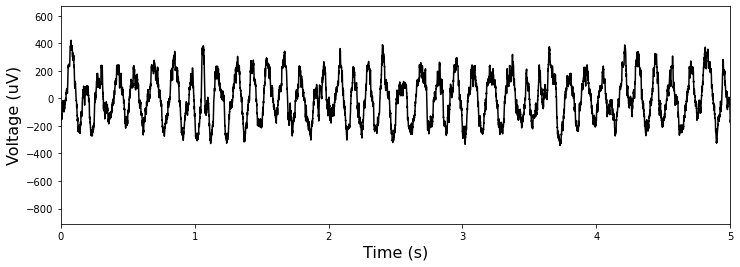

In [6]:
remData = remFolder[13]
arrays = remData["data"]

sig = arrays[3]

times = np.arange(0, len(sig)/fs, 1 / fs)
plt.figure(figsize=(12,4))
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('Voltage (uV)', fontsize=16)
plt.plot(times, sig, color='k', label='raw')
plt.xlim(0, 5)

In [7]:
remFolder[13]["metadata"]

{'RatID': 'Rat4',
 'StudyDay': 'SD17',
 'condition': 'HC',
 'treatment': '0',
 'posttrial_number': 'posttrial5'}

(0.0, 5.0)

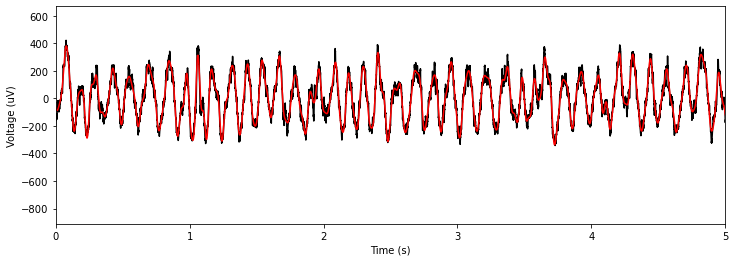

In [8]:
# Apply a Lowpass filter
from neurodsp.filt import filter_signal

sig_low = filter_signal(sig, fs, "lowpass", f_lowpass, n_seconds=lowpass_length, remove_edges=False)
plt.figure(figsize=(12,4))
plt.xlabel('Time (s)')
plt.ylabel('Voltage (uV)')
plt.plot(times, sig, color='k', label='raw')
plt.plot(times, sig_low, color='r', label='lowpass')
plt.xlim(0, 5)

### Segmenting the signal into phasic and tonic episodes

In [9]:
from bycycle.features import compute_features

# Compute cycle-by-cycle features
df = compute_features(sig_low, fs, f_range=f_theta, threshold_kwargs=threshold_bycycle)

# Extract the timestamps and burst detection results
df = df[["sample_last_trough", "sample_next_trough", "is_burst"]]

In [10]:
# Extract the timestamps and burst detection results
df = df[["sample_last_trough", "sample_next_trough", "is_burst"]]
phasic_df = df[df["is_burst"] == True]
tonic_df = df[df["is_burst"] == False]

phasic_df

,sample_last_trough,sample_next_trough,is_burst
516,165607,165873,True
517,165873,166143,True
518,166143,166404,True
519,166404,166628,True
520,166628,166893,True
521,166893,167161,True
522,167161,167428,True
523,167428,167691,True
588,186951,187252,True
589,187252,187453,True


In [11]:
def get_episodes(df_features, threshold_episode):
    l1 = df_features["sample_last_trough"].to_numpy()
    l2 = df_features["sample_next_trough"].to_numpy()

    # Ensure l1 and l2 have the same length
    if len(l1) != len(l2):
        raise ValueError("l1 and l2 must have the same length.")

    # List to store extracted episodes
    episodes = []

    # Assign the start of the first episode
    start = l1[0]
    end = 0

    for i in range(1, len(l1)):
        diff = l1[i] - l2[i - 1]

        if (diff > threshold_episode):
            # Set the end of the current episode
            end = l2[i - 1]
            episodes.append((start, end))
            # Update the start for the next episode
            start = l1[i]

    # Set the end of the last episode
    end = l2[-1]
    episodes.append((start, end))
    return episodes
 
threshold_episode = 2500 # If two cycles are within 2500 sampling points, i.e 1 second, then they are connected

# Connect the consecutive cycles to form an episode 
phasic = get_episodes(phasic_df, threshold_episode=threshold_episode)
tonic = get_episodes(tonic_df, threshold_episode=0)
phasic

[(165607, 167691),
 (186951, 189202),
 (211485, 213821),
 (217236, 219867),
 (228734, 231133)]

In [12]:
tonic

[(346, 165607),
 (167691, 186951),
 (189202, 211485),
 (213821, 217236),
 (219867, 228734),
 (231133, 312454)]

In [13]:
from itertools import chain

start = df["sample_last_trough"].iloc[0]
end = df["sample_next_trough"].iloc[-1]
eps = [start] + list(chain(*phasic)) + [end]
list(zip(eps[::2], eps[1::2]))

[(346, 165607),
 (167691, 186951),
 (189202, 211485),
 (213821, 217236),
 (219867, 228734),
 (231133, 312454)]

In [14]:
list(chain.from_iterable(phasic))

[165607,
 167691,
 186951,
 189202,
 211485,
 213821,
 217236,
 219867,
 228734,
 231133]

In [1]:
from itertools import chain

def segment(self, f_range, threshold_episode, threshold_bycycle):
    if threshold_episode < 1:
        raise ValueError("Invalid value for `threshold_episode` parameter. Should be a positive integer.")
    
    # Run cycle-by-cycle algorithm for burst detection
    df = compute_features(self.filtered["lowpass"], 
                          self.fs,
                          f_range=f_range, 
                          center_extrema='peak',
                          burst_method='cycles',
                          threshold_kwargs=threshold_bycycle)
    
    # Extract the timestamps and burst detection results
    df = df[["sample_last_trough", "sample_next_trough", "is_burst"]]
    phasic_df = df[df["is_burst"] == True]
    tonic_df = df[df["is_burst"] == False]  

    start = df["sample_last_trough"].iloc[0]
    end = df["sample_next_trough"].iloc[-1]

    if len(phasic_df) != 0:
        self.phasic = get_episodes(phasic_df, threshold_episode=threshold_episode)
        eps = [start] + list(chain.from_iterable(phasic)) + [end]
        self.tonic = list(zip(eps[::2], eps[1::2]))
    else:
        self.tonic = [(start, end)]
        

## NeuralSignal approach

We can process the previous steps in an object oriented way.

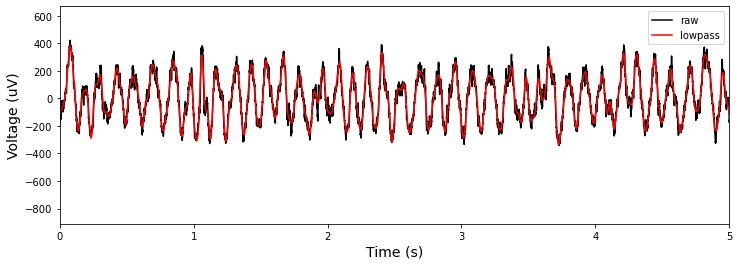

In [15]:
remData = remFolder[13]
arrays = remData["data"]
metadata = remData["metadata"]

theta = NeuralSignal(arrays[3], fs)
theta.filter("lowpass", f_range=f_lowpass, n_seconds=lowpass_length)
theta.plot(xlim=(0,5), figsize=(12,4))

Run the cycle-by-cycle algorithm. We then segment the signal into phasic and tonic episodes.

In [22]:
theta.segment(f_range=f_theta, threshold_episode=threshold_episode, threshold_bycycle=threshold_bycycle)
theta.phasic

[(165607, 167691),
 (186951, 189202),
 (211485, 213821),
 (217236, 219867),
 (228734, 231133)]

In [19]:
segment(theta, f_theta, threshold_episode, threshold_bycycle)

In [21]:
theta.phasic

[(165607, 167691),
 (186951, 189202),
 (211485, 213821),
 (217236, 219867),
 (228734, 231133)]

# Visualizing the data

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

signal = sig_low
t = np.arange(len(signal))/fs
fig = go.Figure(data=go.Scatter(x=t, y=signal, mode='lines', line=dict(color="black")))

fig.update_xaxes(rangeslider_visible=True)
fig.update_layout(title="Rat3 LFP", xaxis_title="Time", yaxis_title="Voltage (uV)")

f = go.FigureWidget(fig)
f